# Customer Intelligence System using Classification, Ensemble Learning & Clustering

## Assignment Description

Built a comprehensive Country Intelligence System leveraging Clustering (K-Means, DBSCAN), Classification, and Ensemble Learning (Random Forest, XGBoost) to segment countries based on socio-economic indicators. The project uncovers development patterns, identifies country groups with similar characteristics, detects outliers, and enables accurate prediction of country segments. The resulting insights support data-driven analysis of global development and socio-economic trends.

##Import Libraries & Load Dataset

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score,
    davies_bouldin_score
)
from scipy.cluster.hierarchy import linkage, dendrogram
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)

df = pd.read_csv('/content/Country-data.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200



**Why are we importing these libraries?**
* **Data & Graphs:** `pandas` and `numpy` handle our data tables, while `matplotlib` and `seaborn` draw the visualizations.
* **Scaling:** `StandardScaler` equalizes our column units (dollars vs. percentages) so no single feature dominates the model.
* **Modeling:** K-Means/DBSCAN group the countries, and ensemble models (Random Forest/XGBoost) classify them.

## Dataset Understanding

In [2]:
print("Dataset Information:\n")
print(df.info())

print("\n" + "="*60)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\n" + "="*60)

print("\nStatistical Summary:\n")
display(df.describe())

print("\n" + "="*60)

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None


Missing Values:

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


Statistical Summary:



,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000




Duplicate Rows: 0


**What did we find from the data?**
* The dataset has **167 rows** (countries) and **10 columns** (socio-economic features).
* The data is clean: there are exactly **zero missing values** to fill.
* The `country` column is text, while all other feature columns are purely numerical.

# Descriptive statistics

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00



**What do these statistics tell us?**
* **Economic Divide:** There is a massive wealth gap; GDP per capita (`gdpp`) ranges from $231 to $105,000.
* **Healthcare Emergency:** Child mortality varies drastically (2.6 to 208 deaths per 1000 births), highlighting countries that need immediate developmental aid.

## Exploratory Data Analysis

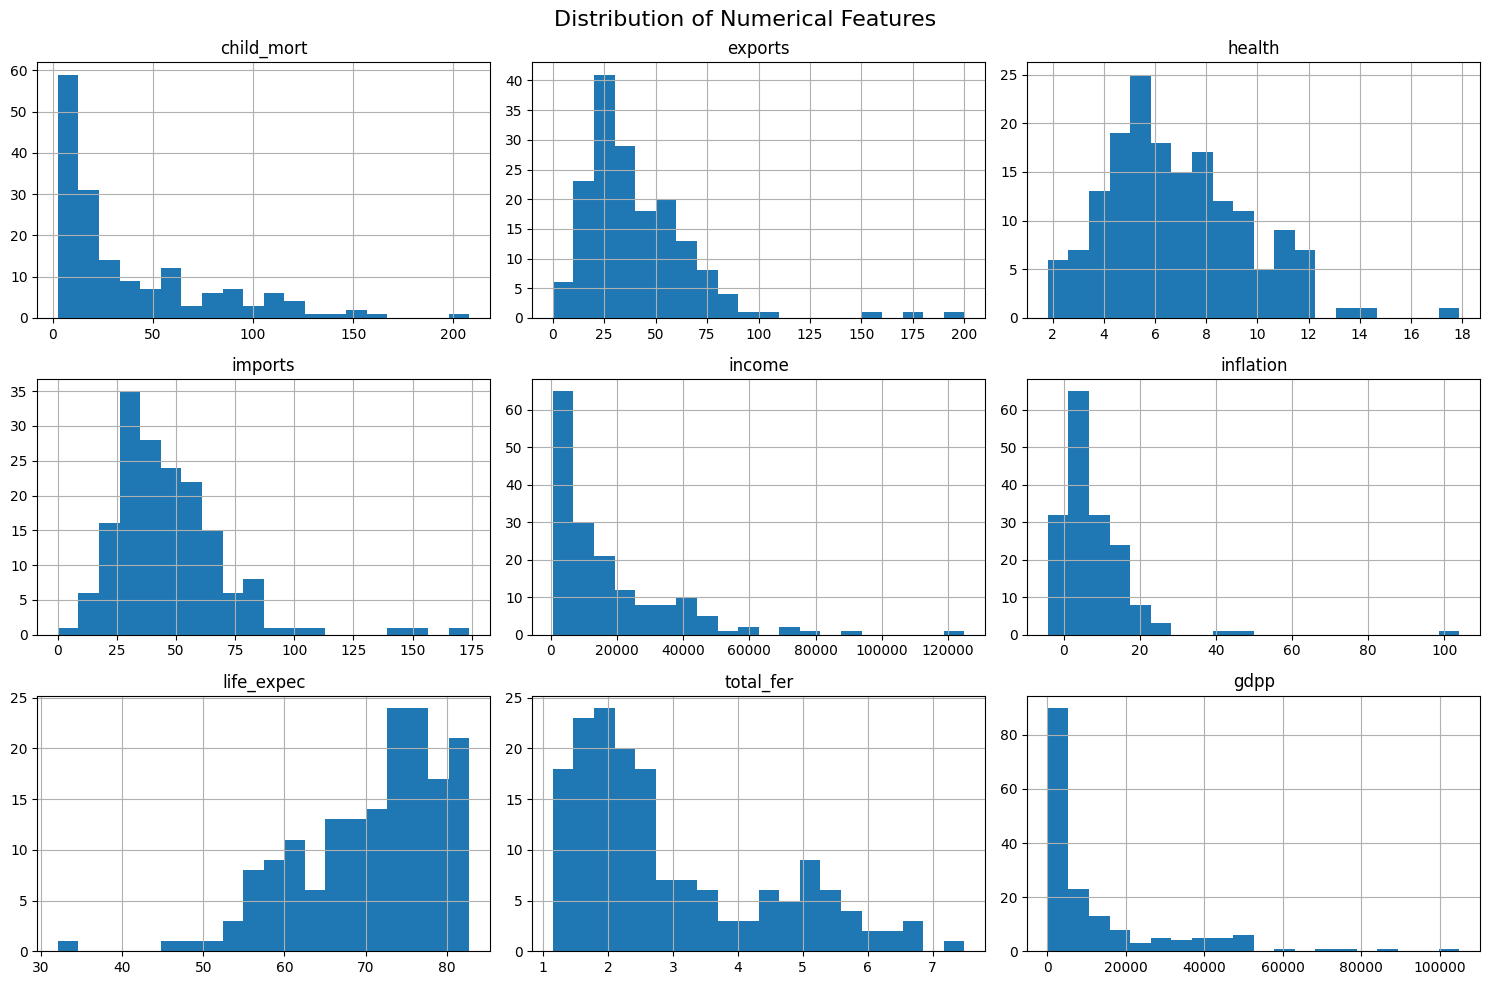

In [4]:
# Histograms for all numerical features

df.drop('country', axis=1).hist(
    figsize=(15,10),
    bins=20
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

**What do these distribution graphs show?**
* **Wealth Concentration:** Economic metrics (like `gdpp` and `income`) are heavily right-skewed, showing that global wealth is concentrated in a few elite nations.
* **Developmental Divide:** Healthcare metrics (like `child_mort` and `total_fer`) are similarly skewed, highlighting a distinct cluster of vulnerable countries facing severe socio-economic challenges.

## Correlation Analysis

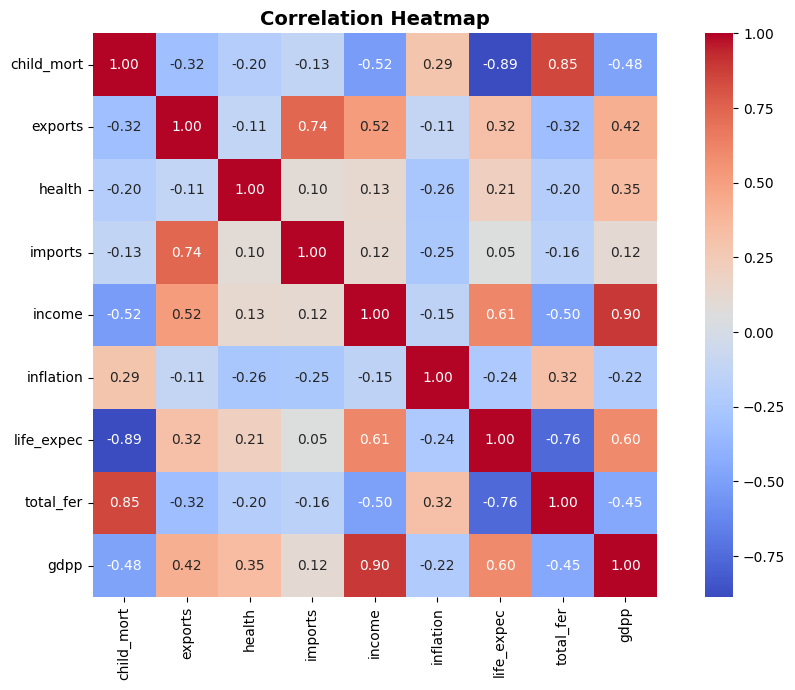

Key Correlations with child_mort:
life_expec   -0.886676
income       -0.524315
gdpp         -0.483032
exports      -0.318093
health       -0.200402
imports      -0.127211
inflation     0.288276
total_fer     0.848478
child_mort    1.000000
Name: child_mort, dtype: float64


In [5]:
features = df.select_dtypes(include=np.number).columns.tolist()
corr = df[features].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key Correlations with child_mort:")
print(corr['child_mort'].sort_values())

**What does this correlation heatmap show?**
* **Income & GDP (+0.90):** Strong positive correlation; wealthier nations naturally have higher citizen incomes.
* **Child Mortality & Life Expectancy (-0.89):** High child mortality severely drags down the overall life expectancy of a country.
* **Child Mortality & Fertility (+0.85):** Countries with higher child mortality also see a higher average number of children per woman.

## Feature Engineering

We convert percentage-based features into actual absolute values:
- `exports`, `imports`, and `health` are currently % of GDP
- Multiplying by `gdpp/100` gives us real economic values

This improves model accuracy and makes features physically interpretable.

In [6]:
df_clean = df.copy()

df_clean['exports'] = (df['exports'] * df['gdpp']) / 100
df_clean['health']  = (df['health']  * df['gdpp']) / 100
df_clean['imports'] = (df['imports'] * df['gdpp']) / 100

print("Feature Engineering Completed ✓")
df_clean.head()

Feature Engineering Completed ✓


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,55.30,41.9174,248.297,1610,9.44,56.2,5.82,553
1,Albania,16.6,1145.20,267.8950,1987.740,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,1712.64,185.9820,1400.440,12900,16.10,76.5,2.89,4460
3,Angola,119.0,2199.19,100.6050,1514.370,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,5551.00,735.6600,7185.800,19100,1.44,76.8,2.13,12200


## Feature Scaling

**Why did we scale the features?**
* Distance-based algorithms (like K-Means and Hierarchical Clustering) are highly sensitive to the scale of numbers.
* `StandardScaler` places everything on an equal playing field (mean of 0, standard deviation of 1) so massive numbers (like $100,000 income) don't dominate small metrics (like 1 to 7 fertility rate).

In [7]:
X_raw = df_clean.drop(
    'country',
    axis=1
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_raw
)

print("Feature Scaling Completed ✓")

Feature Scaling Completed ✓


### Observation
- All numerical features are standardized.
- Mean becomes approximately 0 and standard deviation becomes 1.

## Finding the Optimal Number of Clusters

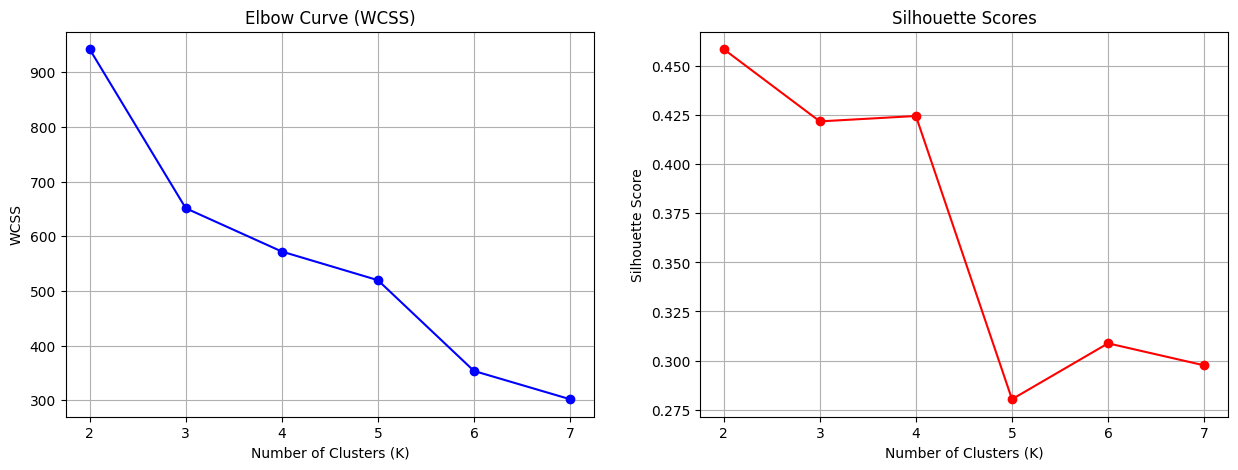

In [8]:
silhouette_vals = []
wcss = []
k_list = range(2, 8)

for k in k_list:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_vals.append(silhouette_score(X_scaled, kmeans.labels_))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(k_list, wcss, 'bo-')
ax1.set_title('Elbow Curve (WCSS)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('WCSS')
ax1.grid(True)


ax2.plot(k_list, silhouette_vals, 'ro-')
ax2.set_title('Silhouette Scores')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True)

plt.show()

### What is the optimal number of clusters?

- **Elbow Curve (WCSS):** The rate of decrease in WCSS begins to slow down around **K = 3**, indicating a natural grouping structure in the data.
- **Silhouette Score:** Although the highest score is observed at **K = 2**, both **K = 3** and **K = 4** maintain strong clustering quality with comparable scores.
- **Decision:** We selected **K = 3** because it provides a good balance between cluster quality, interpretability, and meaningful country segmentation into Underdeveloped, Developing, and Developed groups.

## Hierarchical Clustering (Dendrogram)

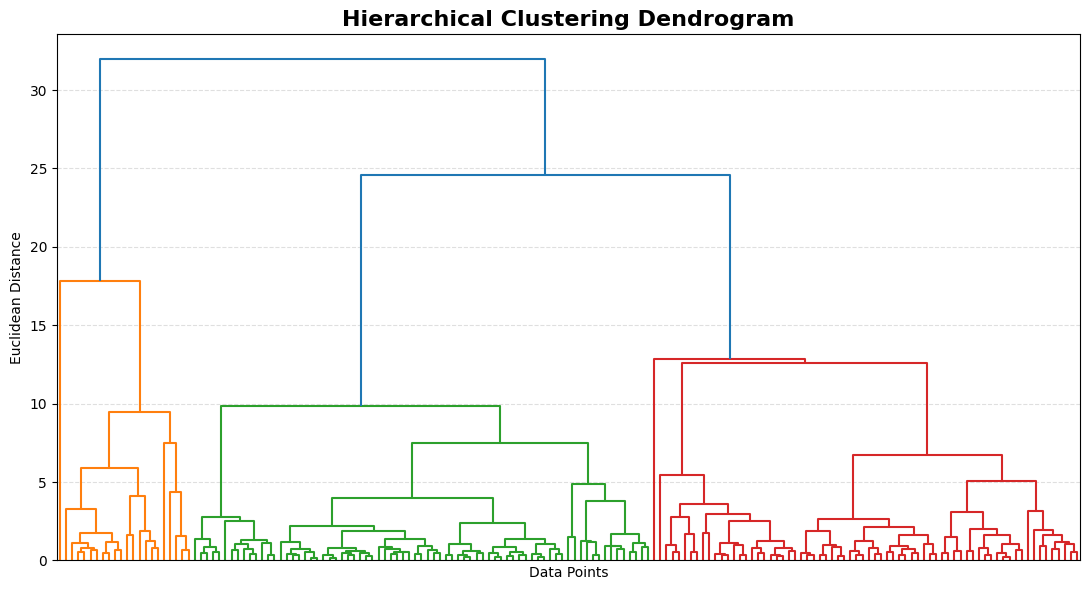

In [9]:
plt.figure(figsize=(11, 6))

linkage_matrix = linkage(X_scaled, method='ward')
dendrogram(linkage_matrix, no_labels=True, color_threshold=None)

plt.title("Hierarchical Clustering Dendrogram", fontsize=16, fontweight='bold')
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Key Insights from the Dendrogram

- Countries with similar socio-economic characteristics are grouped together at lower distances.
- Large vertical gaps indicate well-separated clusters within the dataset.
- The dendrogram suggests the presence of a few major country groups, supporting the use of clustering techniques for segmentation.

## K-Means Clustering

In [10]:
# K-MEANS CLUSTERING (K=3)

kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = kmeans_labels

print("K-Means Completed ✓")
print("\nCluster Counts:\n")
print(df['Cluster'].value_counts().sort_index())

print("\nSilhouette Score     :", round(silhouette_score(X_scaled, kmeans_labels), 4))
print("Davies-Bouldin Score :", round(davies_bouldin_score(X_scaled, kmeans_labels), 4))

K-Means Completed ✓

Cluster Counts:

Cluster
0    48
1    28
2    91
Name: count, dtype: int64

Silhouette Score     : 0.4219
Davies-Bouldin Score : 0.8566


### Observation

- K-Means groups countries with similar socio-economic characteristics into distinct segments..
- The clustering metrics suggest a good balance between cluster separation and compactness.
- These segments represent different development levels and were used as labels for supervised classification.

# Cluster Profile Analysis

In [11]:
cluster_profile = df.groupby('Cluster').mean(numeric_only=True)
display(cluster_profile)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,91.610417,29.571042,6.433542,43.133333,3897.354167,11.911146,59.239583,4.992083,1909.208333
1,5.046429,60.789286,8.934643,51.857143,50178.571429,3.014679,80.514286,1.760714,48114.285714
2,20.357143,41.139440,6.365275,47.343581,13968.021978,7.070549,73.460440,2.235055,7979.912088


In [12]:
# Countries in Each Cluster

for cluster in sorted(df['Cluster'].unique()):
    print(f"\nCluster {cluster}")
    print("-" * 50)

    countries = df[df['Cluster'] == cluster]['country'].tolist()

    print(countries)


Cluster 0
--------------------------------------------------
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'Solomon Islands', 'South Africa', 'Sudan', 'Tanzania', 'Timor-Leste', 'Togo', 'Uganda', 'Yemen', 'Zambia']

Cluster 1
--------------------------------------------------
['Australia', 'Austria', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Denmark', 'Finland', 'France', 'Germany', 'Iceland', 'Ireland', 'Italy', 'Japan', 'Kuwait', 'Luxembourg', 'Malta', 'Netherlands', 'New Zealand', 'Norway', 'Qatar', 'Singapore', 'Spain', 'Sweden', 'Switzerland', 'United Ara

## DBSCAN Clustering



**What is the role of DBSCAN here?**
* Unlike K-Means, DBSCAN doesn't force every country into a cluster; it effectively isolates anomalies.
* It highlights "outlier" nations that have highly exceptional or extreme socio-economic characteristics.

In [13]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=3
)

df['DBSCAN_Cluster'] = dbscan.fit_predict(
    X_scaled
)

print("DBSCAN Completed ✓")

print("\nDBSCAN Cluster Counts:\n")
print(df['DBSCAN_Cluster'].value_counts().sort_index())

DBSCAN Completed ✓

DBSCAN Cluster Counts:

DBSCAN_Cluster
-1     13
 0    151
 1      3
Name: count, dtype: int64


- DBSCAN identified dense country groups and detected unusual countries as outliers.
- The outliers represent nations with unique socio-economic characteristics that differ significantly from the majority.

## Clustering Visualization

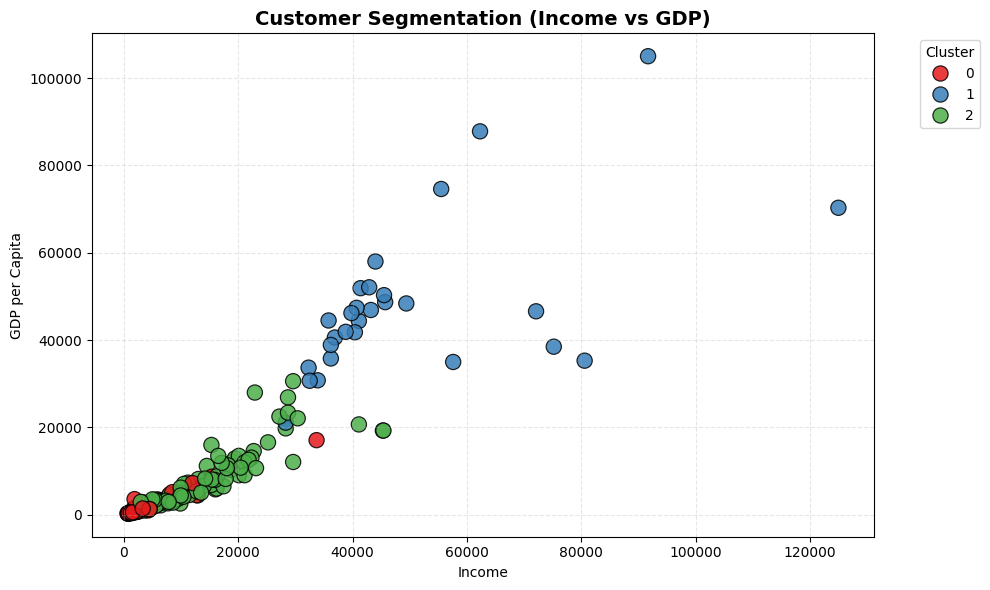

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, x='income', y='gdpp',
    hue='Cluster', palette='Set1',
    s=120, edgecolor='black', alpha=0.85
)

plt.title("Customer Segmentation (Income vs GDP)", fontsize=14, fontweight='bold')
plt.xlabel("Income")
plt.ylabel("GDP per Capita")
plt.grid(alpha=0.3, linestyle='--')
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Key Insights

- Countries with higher income generally exhibit higher GDP per capita.
- The clusters form distinct groups, indicating meaningful socio-economic segmentation.
- A small number of countries appear far from the majority, highlighting economically exceptional nations.

# Segment Creation

In [15]:
gdpp_ranks = df.groupby('Cluster')['gdpp'].mean().sort_values()

mapping = {
    gdpp_ranks.index[0]: 0,  # Lowest GDP  → Underdeveloped
    gdpp_ranks.index[1]: 1,  # Middle GDP  → Developing
    gdpp_ranks.index[2]: 2   # Highest GDP → Developed
}

df['Segment'] = df['Cluster'].map(mapping)

segment_labels = {
    0: "Underdeveloped Countries",
    1: "Developing Countries",
    2: "Developed Countries"
}

print("Segment Created ✓")
print("\nSegment Counts:\n")
print(df['Segment'].value_counts().sort_index())

Segment Created ✓

Segment Counts:

Segment
0    48
1    91
2    28
Name: count, dtype: int64


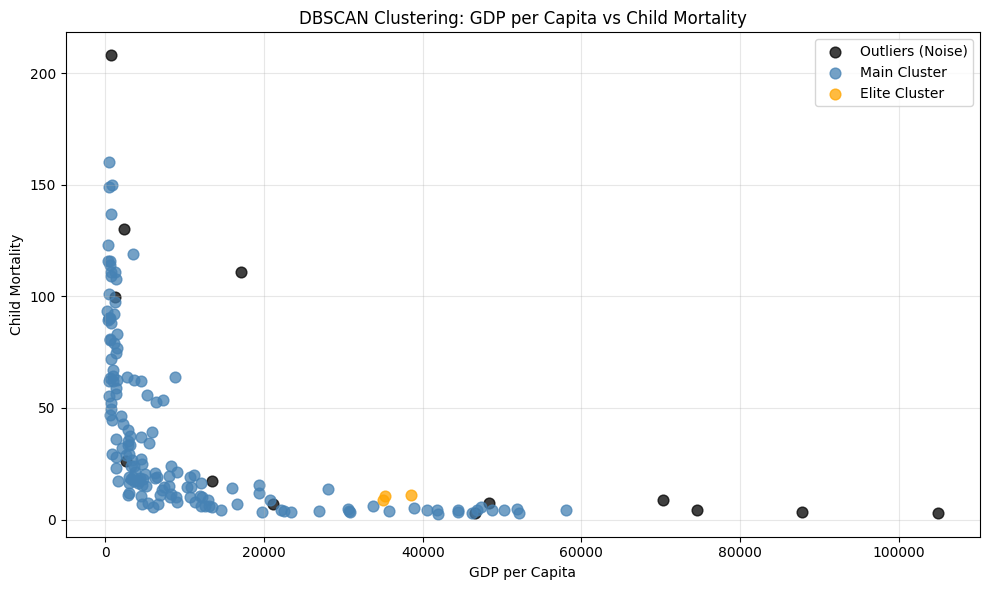

In [16]:
# DBSCAN VISUALIZATION

plt.figure(figsize=(10, 6))

colors_db = {
    -1: 'black',
     0: 'steelblue',
     1: 'orange'
}

labels_db = {
    -1: 'Outliers (Noise)',
     0: 'Main Cluster',
     1: 'Elite Cluster'
}

for cluster in sorted(df['DBSCAN_Cluster'].unique()):

    mask = df['DBSCAN_Cluster'] == cluster

    plt.scatter(
        df.loc[mask, 'gdpp'],
        df.loc[mask, 'child_mort'],
        color=colors_db.get(cluster, 'grey'),
        label=labels_db.get(cluster, f'Cluster {cluster}'),
        alpha=0.75,
        s=60
    )

plt.title('DBSCAN Clustering: GDP per Capita vs Child Mortality')
plt.xlabel('GDP per Capita')
plt.ylabel('Child Mortality')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**What it Shows:**
* **Main Cluster:** The vast majority of nations follow a dense, standard developmental trajectory.
* **Elite Cluster:** A small, distinct group of countries exhibiting exceptionally high GDP and low child mortality.
* **Outliers (Noise):** Specific nations with highly unusual socio-economic conditions that significantly deviate from standard global patterns.

In [17]:
# DBSCAN Outlier Countries

outliers = df[df["DBSCAN_Cluster"] == -1]["country"].tolist()

print("Number of Outlier Countries:", len(outliers))
print("\nOutlier Countries:\n")
print(outliers)

Number of Outlier Countries: 13

Outlier Countries:

['Equatorial Guinea', 'Haiti', 'Lesotho', 'Luxembourg', 'Malta', 'Mongolia', 'Nigeria', 'Norway', 'Qatar', 'Singapore', 'Switzerland', 'United States', 'Venezuela']


## Preparing Data for Classification

**How are we transitioning to classification?**
* We use the K-Means cluster labels as our new target variable (`y`).
* The data is split into **80% training** and **20% testing** sets to train predictive models on these segments.

In [18]:
# TRAIN TEST SPLIT

X = df_clean.drop(
    columns=[
        'country',
        'Cluster',
        'DBSCAN_Cluster',
        'Segment'
    ],
    errors='ignore'
)

y = df['Segment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train Test Split Completed ✓")

print("\nFeatures Used:")
print(X.columns.tolist())

print("\nShape:", X.shape)

Train Test Split Completed ✓

Features Used:
['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

Shape: (167, 9)


## Random Forest Classification



      Random Forest Results

Accuracy: 0.9706

Classification Report:

                precision    recall  f1-score   support

Underdeveloped       1.00      1.00      1.00        10
    Developing       0.95      1.00      0.97        18
     Developed       1.00      0.83      0.91         6

      accuracy                           0.97        34
     macro avg       0.98      0.94      0.96        34
  weighted avg       0.97      0.97      0.97        34



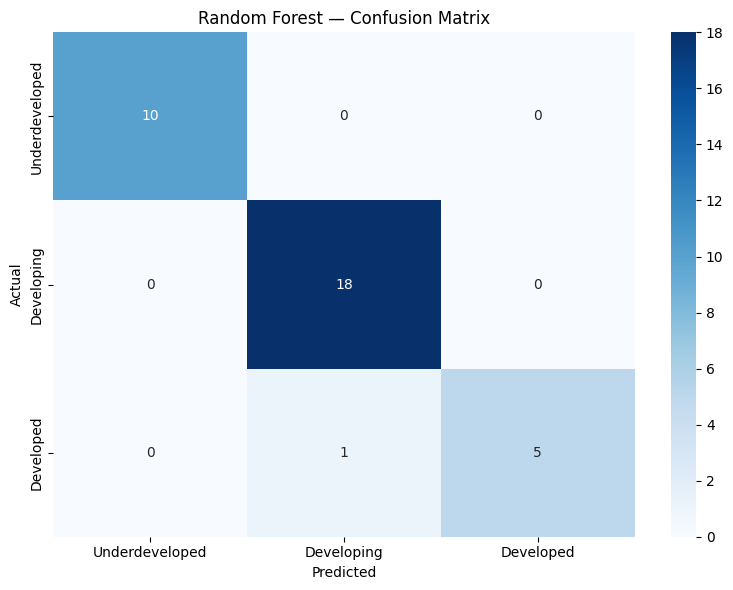

In [19]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

class_names = ["Underdeveloped", "Developing", "Developed"]

print("="*40)
print("      Random Forest Results")
print("="*40)

print(f"\nAccuracy: {rf_acc:.4f}")

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=class_names,
        zero_division=0
    )
)

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Model Insight
- Random Forest achieved strong classification performance.
- Most cluster labels were predicted correctly.

## XGBoost Classification

         XGBoost Results

Accuracy: 0.9706

Classification Report:

                precision    recall  f1-score   support

Underdeveloped       1.00      1.00      1.00        10
    Developing       0.95      1.00      0.97        18
     Developed       1.00      0.83      0.91         6

      accuracy                           0.97        34
     macro avg       0.98      0.94      0.96        34
  weighted avg       0.97      0.97      0.97        34



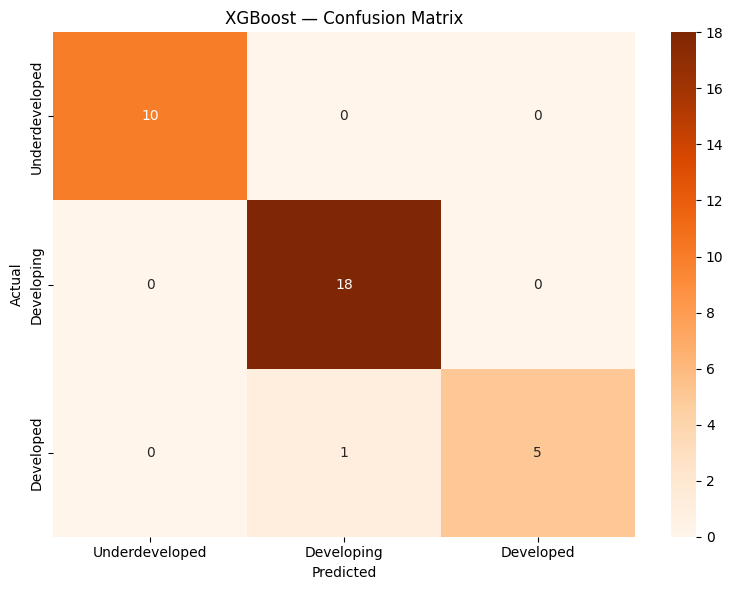

In [20]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

class_names = [
    "Underdeveloped",
    "Developing",
    "Developed"
]

print("="*40)
print("         XGBoost Results")
print("="*40)

print(f"\nAccuracy: {xgb_acc:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=class_names,
        zero_division=0
    )
)

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("XGBoost — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## Model Comparison

In [21]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

comparison['Accuracy'] = comparison['Accuracy'].round(4)

comparison

,Model,Accuracy
0,Random Forest,0.9706
1,XGBoost,0.9706


## Model Performance Comparison

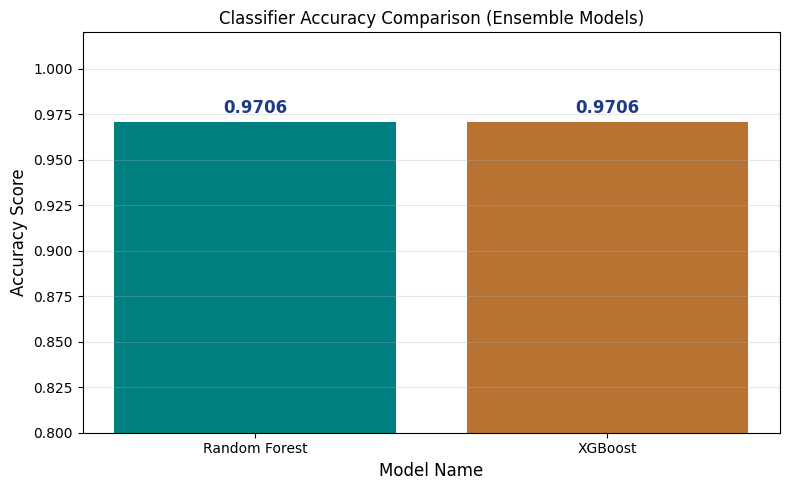

In [22]:
comparison_df = pd.DataFrame({
    'Model Name': ['Random Forest', 'XGBoost'],
    'Accuracy Score': [rf_acc, xgb_acc]
})

comparison_df

plt.figure(figsize=(8, 5))

bar_colors = ["#008080", "#B87333"]

bars = plt.bar(
    comparison_df['Model Name'],
    comparison_df['Accuracy Score'],
    color=bar_colors
)

plt.title('Classifier Accuracy Comparison (Ensemble Models)')
plt.xlabel('Model Name', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)

plt.ylim(0.80, 1.02)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f'{height:.4f}',
        ha='center',
        fontsize=12,
        fontweight='bold',
        color="#1E3A8A"
    )

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### How well did the models perform?

- Both Random Forest and XGBoost achieved an excellent accuracy of **97.06%**.
- Both models demonstrated strong predictive capability for country segment classification.
- Either model can be reliably used for future country development predictions.

## Best Model Selection

In [23]:
model_scores = {
    'Random Forest': rf_acc,
    'XGBoost': xgb_acc
}

best_model = max(
    model_scores,
    key=model_scores.get
)

best_accuracy = model_scores[best_model]

print("="*40)
print("      Best Performing Model")
print("="*40)

print(f"\nModel    : {best_model}")
print(f"Accuracy : {best_accuracy:.4f}")

      Best Performing Model

Model    : Random Forest
Accuracy : 0.9706


## Feature Importance Analysis

,Feature,Importance
0,child_mort,0.197921
8,gdpp,0.178078
6,life_expec,0.170098
7,total_fer,0.148743
4,income,0.124343
1,exports,0.071966
2,health,0.053380
3,imports,0.043070
5,inflation,0.012400


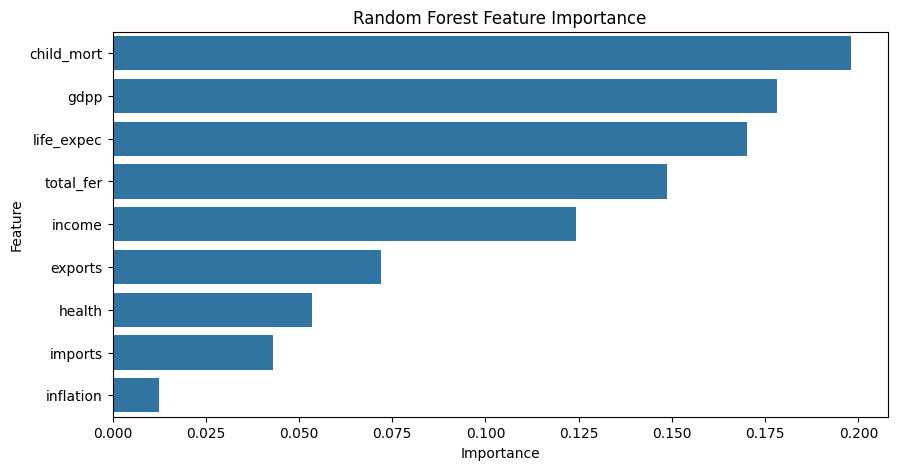

In [24]:
# Random Forest Feature Importance

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by='Importance',
    ascending=False
)

display(rf_importance)

plt.figure(figsize=(10,5))

sns.barplot(
    data=rf_importance,
    x='Importance',
    y='Feature'
)

plt.title("Random Forest Feature Importance")
plt.show()

,Feature,Importance
8,gdpp,0.452783
0,child_mort,0.282932
6,life_expec,0.116886
7,total_fer,0.068214
1,exports,0.023132
3,imports,0.022188
4,income,0.018516
2,health,0.011548
5,inflation,0.003801


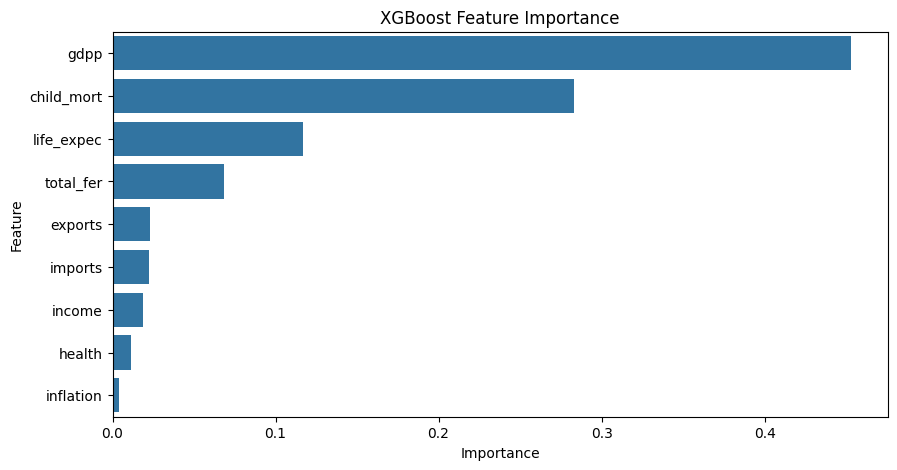

In [25]:
# XGBoost Feature Importance

xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by='Importance',
    ascending=False
)

display(xgb_importance)

plt.figure(figsize=(10,5))

sns.barplot(
    data=xgb_importance,
    x='Importance',
    y='Feature'
)

plt.title("XGBoost Feature Importance")
plt.show()

## Segment Count Summary

In [26]:
segment_summary = pd.DataFrame({
    'Segment': [0, 1, 2],
    'Total_Countries': [
        (df['Segment'] == 0).sum(),
        (df['Segment'] == 1).sum(),
        (df['Segment'] == 2).sum()
    ],
    'Segment_Name': [
        'Underdeveloped Countries',
        'Developing Countries',
        'Developed Countries'
    ]
})

segment_summary

,Segment,Total_Countries,Segment_Name
0,0,48,Underdeveloped Countries
1,1,91,Developing Countries
2,2,28,Developed Countries


# Final Conclusion & Strategic Insights

### Clustering Results
- K-Means successfully segmented the 167 countries into three meaningful groups:
  - **Underdeveloped Countries:** 48
  - **Developing Countries:** 91
  - **Developed Countries:** 28
- This segmentation provides a structured understanding of global socio-economic development levels.

### Anomaly Detection
- DBSCAN identified a major country cluster, a small elite cluster, and several outlier nations.
- These outliers represent countries with unique socio-economic characteristics that differ significantly from the majority.

### Model Performance
- Both **Random Forest** and **XGBoost** achieved an excellent classification accuracy of **97.06%**.
- The strong predictive performance confirms that the generated country segments are reliable and highly predictable.

### Key Drivers of Development
Model analysis revealed that global development is heavily dictated by three primary indicators:
* **GDP per capita (`gdpp`):** The absolute strongest indicator, representing a nation's overall economic output and financial strength.
* **Child Mortality (`child_mort`):** The second most critical feature, acting as a direct proxy for the quality and accessibility of the national healthcare system.
* **Average Income (`income`):** The third key driver, reflecting the everyday living standards and purchasing power of the population.

### Strategic Insights
- Countries with higher GDP per capita and income generally exhibit better development outcomes.
- Lower child mortality rates are strongly associated with improved healthcare systems and quality of life.
- The combination of economic and healthcare indicators provides a comprehensive measure of national development.

### Final Insight
- The Customer Intelligence System successfully transformed raw socio-economic data into meaningful country intelligence using clustering, outlier detection, and predictive modeling.
- The analysis demonstrates that economic prosperity and healthcare quality are the strongest determinants of a country's development level, enabling data-driven decision-making and strategic planning.